In [ ]:
# Swiggy Sales Analysis
# Importing Libraries
import pandas as pd          # Used for data manipulation and analysis (like working with tables/dataframes)
import numpy as np           # Used for numerical operations (arrays, mathematical calculations)
import matplotlib.pyplot as plt   # Used for creating basic static charts and graphs
import seaborn as sns        # Used for advanced and more attractive statistical visualizations
import plotly.express as px  # Used to create interactive charts (zoom, hover, dynamic visuals)

In [ ]:
df=pd.read_excel("/content/swiggy_data.xlsx")
df.head()# printing first 10 row value

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [ ]:
df.tail() # To see Last 5 rows

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [ ]:
# To see the Shap of the data number of rows in data
print("No_Of_Rows:" ,df.shape[0])

No_Of_Rows: 197430


In [ ]:
# To see the Shap of the data no.of column
print("No_Of_Columns(Fields):" ,df.shape[1])

No_Of_Columns(Fields): 10


In [ ]:
#Checking Data Type
df.dtypes

,0
State,object
City,object
Order Date,datetime64[ns]
Restaurant Name,object
Location,object
Category,object
Dish Name,object
Price (INR),float64
Rating,float64
Rating Count,int64


In [ ]:
df.describe() # If you want to check mean,median ,mode,max,min

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [ ]:
# Total Sales Am Checking
total_sales=df["Price (INR)"].sum()
print("Total Sales:",round(total_sales)) # i have used round function for rounding off the numbers

Total Sales: 53012506


In [ ]:
average_rate=df["Rating"].mean() # Avg rate
print("Avg_Rate:",round(average_rate,2))

Avg_Rate: 4.34


In [ ]:
# Avgrage order value
Average_order_value=df["Price (INR)"].mean()
print("Average_order_value:",round(Average_order_value,2))

Average_order_value: 268.51


In [ ]:
# rating Count
rating_count=df["Rating Count"].sum()
print("Rating_count:",round(rating_count))

Rating_count: 5591574


In [ ]:
total_orders=len(df)
print("Total_orders:",round(total_orders))

Total_orders: 197430


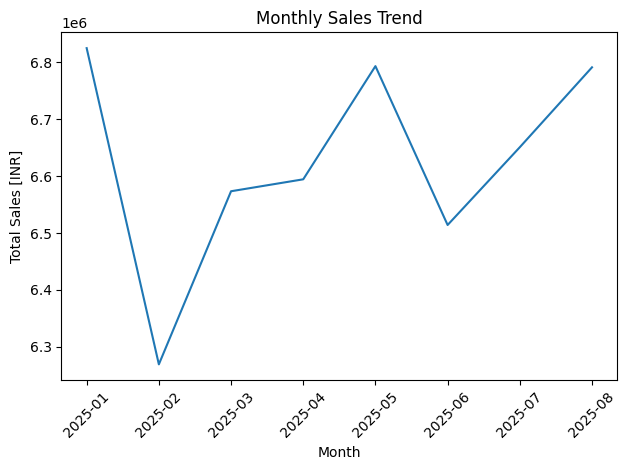

In [ ]:
# Monthly Sales Trend

# Convert 'Order Date' column to datetime format (important for date operations)
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract Year and Month from 'Order Date' (format: YYYY-MM like 2025-01)
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

# Group data by YearMonth and calculate total revenue for each month
monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

# Create a new figure for plotting
plt.figure()

# Plot line chart: X-axis = Month, Y-axis = Total Sales
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Price (INR)"])

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Label for X-axis
plt.xlabel("Month")

# Label for Y-axis
plt.ylabel("Total Sales [INR]")

# Title of the chart
plt.title("Monthly Sales Trend")

# Adjust layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()

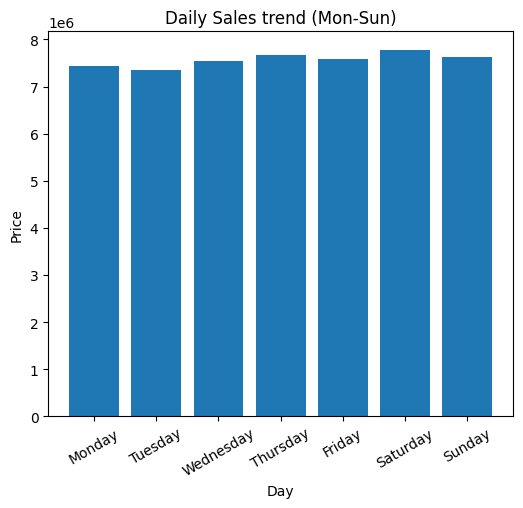

In [ ]:
# Daily Sales Trend

# Extract day name (Monday, Tuesday, etc.) from 'Order Date'
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

# Group data by day name and calculate total revenue for each day
daily_revenue = (
    df.groupby("DayName")["Price (INR)"]  # Group by day
    .sum()                                # Sum total sales for each day
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
    # Reorder days correctly (default order may be random/alphabetical)
)

# Create a figure with specified size
plt.figure(figsize=(6,5))

# Create a bar chart: X-axis = Days, Y-axis = Sales
plt.bar(daily_revenue.index, daily_revenue.values)

# Title of the chart
plt.title("Daily Sales trend (Mon-Sun)")

# Label for X-axis
plt.xlabel("Day")

# Label for Y-axis
plt.ylabel("Price")

# Rotate x-axis labels slightly for better visibility
plt.xticks(rotation=30)

# Display the chart
plt.show()

In [ ]:
# Total Sales by Veg and Non-veg

# Creating a list of keywords that indicate non-veg items
non_veg_keywords = [
    "egg", "fish", "chicken", "mutton", "prawn", "biryani", "kebab", "non-veg", "non veg"
]

# Create a new column 'FoodCategory' based on dish name
df["FoodCategory"] = np.where(

    # Check if 'Dish Name' contains any non-veg keyword (case insensitive)
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),

    "Non-veg",  # If condition is True → mark as Non-veg

    "Veg"       # If condition is False → mark as Veg
)

In [ ]:
#calculate total rev for veg and non veg categories
food_rev=(df.groupby("FoodCategory")["Price (INR)"].sum().reset_index())

In [ ]:
import plotly.express as px  #used for create interactive charts(zoom,hover,dynamic visuals)

In [ ]:
 #create a donut pie chart
fig=px.pie(
     food_rev,values="Price (INR)",
     names="FoodCategory",
     hole=0.5,
     title="revenue contribution:veg vs non_veg")

 #customize slices
fig.update_traces(
     textinfo="percent+label",
     pull=[0.05,0])

#adjust layout settings
fig.update_layout(
    height=500,
    margin=dict(t=30,b=0,l=0,r=0))

#show the interactive chart
fig.show()


In [ ]:

#convert  "Order  date" column  to  dataframe
df["Order Date"]=pd.to_datetime(df["Order Date"])
#create a new column  "Quarter"(eg.2025Q1,2025Q2)
df["Quarter"]=df["Order Date"].dt.to_period("Q").astype(str)
#create quartely  summary
quartely_summary=(
    df.groupby("Quarter",as_index=False)
.agg(
    total_sales=("Price (INR)","sum"),
    avg_rating=("Rating","mean"),
    total_orders=("Order Date","count"))
.sort_values("Quarter")
)

#Round  total sales to  nearest whole number
quartely_summary["total_sales"]=quartely_summary["total_sales"].round(0)
quartely_summary["avg_rating"]=quartely_summary["avg_rating"].round(2)
quartely_summary

,Quarter,total_sales,avg_rating,total_orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


In [ ]:
#group data by cities
top_5_cities=(
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values(ascending=False)
    .reset_index()
)

#create horizontal bar chart
fig=px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    color="City",
    title="top 5 cities by sales(INR)",
    color_discrete_sequence=[
        "red",
        "blue",
        "green",
        "maroon",
        "pink"
    ]
)

#show chart
fig.show()

In [ ]:
import plotly.express as px  # Import Plotly for interactive visualizations

# Total Sales by State

# Create a horizontal bar chart
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()   # Group by State and calculate total revenue
      .sort_values("Price (INR)", ascending=False),            # Sort states by highest revenue

    x="Price (INR)",        # X-axis → Total revenue
    y="State",              # Y-axis → State names
    orientation="h",        # Horizontal bar chart
    title="Revenue (INR) by State"  # Chart title
)

# Customize layout
fig.update_layout(
    height=600,                               # Set chart height
    yaxis=dict(autorange="reversed")           # Show highest revenue at the top
)

# Display the interactive chart
fig.show()